In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import tensorflow as tf

from pathlib import Path
from datetime import datetime
import json

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Xarray:", xr.__version__)
print("TensorFlow:", tf.__version__)

print("Setup complete.")

NumPy: 2.1.3
Pandas: 2.2.3
Xarray: 2025.12.0
TensorFlow: 2.20.0
Setup complete.


In [3]:
oisst_ncss_url = (
    "https://psl.noaa.gov/thredds/ncss/grid/"
    "Datasets/noaa.oisst.v2.highres/"
    "sst.week.mean.nc"
)

print("NOAA OISST Weekly NCSS URL:")
print(oisst_ncss_url)

NOAA OISST Weekly NCSS URL:
https://psl.noaa.gov/thredds/ncss/grid/Datasets/noaa.oisst.v2.highres/sst.week.mean.nc


In [4]:
import requests

response = requests.get(
    oisst_ncss_url,
    params={
        "var": "sst",
        "north": 30,
        "south": -30,
        "west": 40,
        "east": 120,
        "time_start": "2020-01-01T00:00:00Z",
        "time_end": "2020-02-01T00:00:00Z",
        "accept": "netcdf4"
    }
)

print("Status code:", response.status_code)
print("Content type:", response.headers.get("Content-Type"))
print("Size:", len(response.content), "bytes")

Status code: 200
Content type: application/x-netcdf
Size: 803767 bytes


In [5]:
from pathlib import Path

test_file = Path("oisst_test.nc")

test_file.write_bytes(
    response.content
)

print(
    "Saved:",
    test_file,
    "| Size:",
    test_file.stat().st_size,
    "bytes"
)

Saved: oisst_test.nc | Size: 803767 bytes


In [6]:
test_ds = xr.open_dataset(
    test_file
)

print(test_ds)

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 6, lat: 241, lon: 321)
Coordinates:
  * time     (time) datetime64[ns] 48B 2019-12-29 2020-01-05 ... 2020-02-02
  * lat      (lat) float32 964B -29.88 -29.62 -29.38 ... 29.62 29.88 30.12
  * lon      (lon) float32 1kB 40.12 40.38 40.62 40.88 ... 119.6 119.9 120.1
Data variables:
    sst      (time, lat, lon) float32 2MB ...
Attributes: (12/13)
    Conventions:         CF-1.5
    title:               NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea...
    institution:         NOAA/National Centers for Environmental Information
    source:              NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface...
    References:          https://www.psl.noaa.gov/data/gridded/data.noaa.oiss...
    dataset_title:       NOAA Daily Optimum Interpolation Sea Surface Tempera...
    ...                  ...
    comment:             Reynolds, et al.(2007) Daily High-Resolution-Blended...
    History:             Translated to CF-1.0 Conventions by Net

In [7]:
print("Dimensions:")
print(test_ds.dims)

print("\nVariables:")
print(list(test_ds.data_vars))

print("\nCoordinates:")
print(test_ds.coords)

Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 6, 'lat': 241, 'lon': 321})

Variables:
['sst']

Coordinates:
Coordinates:
  * time     (time) datetime64[ns] 48B 2019-12-29 2020-01-05 ... 2020-02-02
  * lat      (lat) float32 964B -29.88 -29.62 -29.38 ... 29.62 29.88 30.12
  * lon      (lon) float32 1kB 40.12 40.38 40.62 40.88 ... 119.6 119.9 120.1


In [8]:
print(test_ds["sst"])

<xarray.DataArray 'sst' (time: 6, lat: 241, lon: 321)> Size: 2MB
[464166 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 48B 2019-12-29 2020-01-05 ... 2020-02-02
  * lat      (lat) float32 964B -29.88 -29.62 -29.38 ... 29.62 29.88 30.12
  * lon      (lon) float32 1kB 40.12 40.38 40.62 40.88 ... 119.6 119.9 120.1
Attributes:
    long_name:      Weekly Mean of Sea Surface Temperature
    units:          degC
    valid_range:    [-3. 45.]
    precision:      2.0
    dataset:        NOAA High-resolution Blended Analysis
    var_desc:       Sea Surface Temperature
    level_desc:     Surface
    statistic:      Weekly Mean
    parent_stat:    Individual Observations
    standard_name:  sea_surface_temperature
    actual_range:   [-1.8000001 32.14     ]


In [9]:
print(
    "Start:",
    test_ds.time.values[0]
)

print(
    "End:",
    test_ds.time.values[-1]
)

print(
    "Number of weeks:",
    len(test_ds.time)
)

Start: 2019-12-29T00:00:00.000000000
End: 2020-02-02T00:00:00.000000000
Number of weeks: 6


In [10]:
print(
    "Latitude:",
    float(test_ds.lat.min()),
    "to",
    float(test_ds.lat.max())
)

print(
    "Longitude:",
    float(test_ds.lon.min()),
    "to",
    float(test_ds.lon.max())
)

Latitude: -29.875 to 30.125
Longitude: 40.125 to 120.125


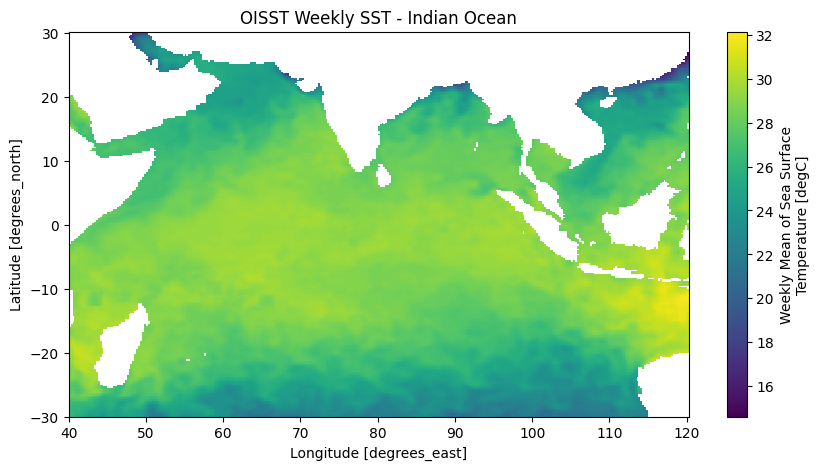

In [11]:
plt.figure(figsize=(10, 5))

test_ds["sst"].isel(time=0).plot()

plt.title("OISST Weekly SST - Indian Ocean")

plt.show()

In [12]:
# ============================================
# CELL 11 — Historical OISST Configuration
# ============================================

START_DATE = "1981-09-01"
END_DATE   = "2026-09-01"

# Region covering both IOD boxes
NORTH = 30
SOUTH = -30
WEST  = 40
EAST  = 120

# Original OISST resolution = 0.25°
# Every 4th point ≈ 1° resolution
HORIZ_STRIDE = 4

print("Historical period:")
print(START_DATE, "to", END_DATE)

print("\nRegion:")
print(f"Latitude : {SOUTH}° to {NORTH}°")
print(f"Longitude: {WEST}° to {EAST}°")

print("\nHorizontal stride:", HORIZ_STRIDE)
print("Approximate spatial resolution: 1°")

Historical period:
1981-09-01 to 2026-09-01

Region:
Latitude : -30° to 30°
Longitude: 40° to 120°

Horizontal stride: 4
Approximate spatial resolution: 1°


In [13]:
# ============================================
# CELL 12 — Create Project Folders
# ============================================

data_dir = Path("saarthi_iod_data")
artifact_dir = Path("saarthi_iod_artifacts")

data_dir.mkdir(exist_ok=True)
artifact_dir.mkdir(exist_ok=True)

print("Data folder:", data_dir.resolve())
print("Artifact folder:", artifact_dir.resolve())

Data folder: /content/saarthi_iod_data
Artifact folder: /content/saarthi_iod_artifacts


In [14]:
# ============================================
# CELL 13 — NCSS Download Function
# ============================================

import requests

def download_oisst_chunk(start_date, end_date, output_file):

    params = {
        "var": "sst",

        "north": NORTH,
        "south": SOUTH,
        "west": WEST,
        "east": EAST,

        "time_start": f"{start_date}T00:00:00Z",
        "time_end": f"{end_date}T00:00:00Z",

        "horizStride": HORIZ_STRIDE,

        "accept": "netcdf4"
    }

    print(f"Downloading {start_date} → {end_date}")

    response = requests.get(
        oisst_ncss_url,
        params=params,
        timeout=300
    )

    print("Status:", response.status_code)
    print(
        "Downloaded:",
        round(len(response.content) / 1024 / 1024, 2),
        "MB"
    )

    response.raise_for_status()

    output_file = Path(output_file)
    output_file.write_bytes(response.content)

    print("Saved:", output_file)

    return output_file

In [15]:
# ============================================
# CELL 14 — Historical Test Download
# ============================================

test_historical_file = (
    data_dir / "oisst_1981_1990_test.nc"
)

download_oisst_chunk(
    "1981-09-01",
    "1990-01-01",
    test_historical_file
)

Status: 200
Downloaded: 4.16 MB
Saved: saarthi_iod_data/oisst_1981_1990_test.nc


PosixPath('saarthi_iod_data/oisst_1981_1990_test.nc')

In [16]:
historical_test_ds = xr.open_dataset(
    test_historical_file
)

print(historical_test_ds)

<xarray.Dataset> Size: 9MB
Dimensions:  (time: 435, lat: 61, lon: 81)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1981-09-06 1981-09-13 ... 1989-12-31
  * lat      (lat) float32 244B -29.88 -28.88 -27.88 ... 28.12 29.12 30.12
  * lon      (lon) float32 324B 40.12 41.12 42.12 43.12 ... 118.1 119.1 120.1
Data variables:
    sst      (time, lat, lon) float32 9MB ...
Attributes: (12/13)
    Conventions:         CF-1.5
    title:               NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea...
    institution:         NOAA/National Centers for Environmental Information
    source:              NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface...
    References:          https://www.psl.noaa.gov/data/gridded/data.noaa.oiss...
    dataset_title:       NOAA Daily Optimum Interpolation Sea Surface Tempera...
    ...                  ...
    comment:             Reynolds, et al.(2007) Daily High-Resolution-Blended...
    History:             Translated to CF-1.0 Conventions by Ne

In [17]:
print("Dimensions:")
print(historical_test_ds.dims)

print("\nSST shape:")
print(historical_test_ds["sst"].shape)

print("\nVariables:")
print(list(historical_test_ds.data_vars))

Dimensions:
FrozenMappingWarningOnValuesAccess({'time': 435, 'lat': 61, 'lon': 81})

SST shape:
(435, 61, 81)

Variables:
['sst']


In [18]:
lat_values = historical_test_ds.lat.values
lon_values = historical_test_ds.lon.values

print("Number of latitude points :", len(lat_values))
print("Number of longitude points:", len(lon_values))

print(
    "\nLatitude spacing:",
    np.mean(np.diff(lat_values)),
    "degrees"
)

print(
    "Longitude spacing:",
    np.mean(np.diff(lon_values)),
    "degrees"
)

Number of latitude points : 61
Number of longitude points: 81

Latitude spacing: 1.0 degrees
Longitude spacing: 1.0 degrees


In [19]:
sst_test = historical_test_ds["sst"]

print("Minimum SST:", float(sst_test.min()))
print("Maximum SST:", float(sst_test.max()))
print("Mean SST   :", float(sst_test.mean()))

print(
    "\nMissing values:",
    int(sst_test.isnull().sum())
)

Minimum SST: 9.026666641235352
Maximum SST: 35.396663665771484
Mean SST   : 26.51671028137207

Missing values: 580725


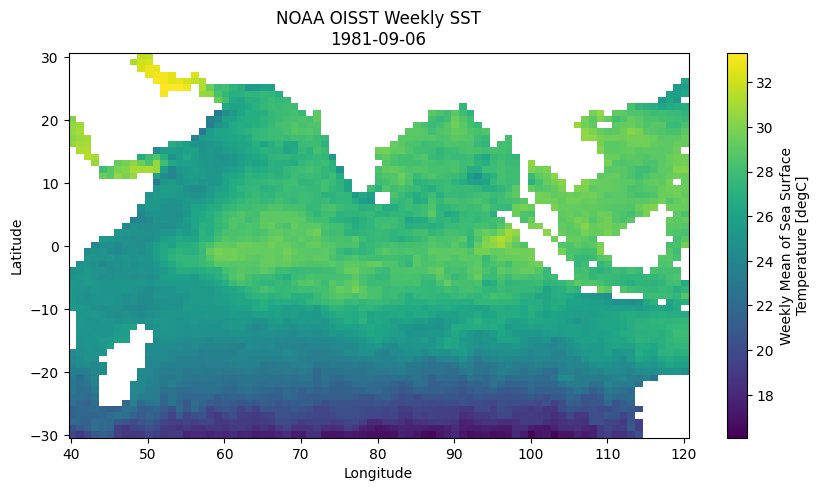

In [20]:
plt.figure(figsize=(10, 5))

historical_test_ds["sst"].isel(time=0).plot()

plt.title(
    "NOAA OISST Weekly SST\n"
    + str(historical_test_ds.time.values[0])[:10]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [21]:
print(
    "First available week:",
    historical_test_ds.time.values[0]
)

print(
    "Last available week:",
    historical_test_ds.time.values[-1]
)

print(
    "Number of weekly observations:",
    len(historical_test_ds.time)
)

First available week: 1981-09-06T00:00:00.000000000
Last available week: 1989-12-31T00:00:00.000000000
Number of weekly observations: 435


In [22]:
# ============================================
# CELL 21 — Define Historical Chunks
# ============================================

chunks = [
    ("1981-09-01", "1990-01-01", "oisst_1981_1989.nc"),
    ("1990-01-01", "2000-01-01", "oisst_1990_1999.nc"),
    ("2000-01-01", "2010-01-01", "oisst_2000_2009.nc"),
    ("2010-01-01", "2020-01-01", "oisst_2010_2019.nc"),
    ("2020-01-01", "2026-09-01", "oisst_2020_2026.nc")
]

print("Number of chunks:", len(chunks))

for start, end, filename in chunks:
    print(f"{start} → {end} : {filename}")

Number of chunks: 5
1981-09-01 → 1990-01-01 : oisst_1981_1989.nc
1990-01-01 → 2000-01-01 : oisst_1990_1999.nc
2000-01-01 → 2010-01-01 : oisst_2000_2009.nc
2010-01-01 → 2020-01-01 : oisst_2010_2019.nc
2020-01-01 → 2026-09-01 : oisst_2020_2026.nc


In [23]:
# ============================================
# CELL 22 — Download Full Historical Dataset
# ============================================

downloaded_files = []

for start_date, end_date, filename in chunks:

    output_file = data_dir / filename

    # Skip if already downloaded
    if output_file.exists():
        print("\nAlready exists:", output_file)
        downloaded_files.append(output_file)
        continue

    try:
        download_oisst_chunk(
            start_date,
            end_date,
            output_file
        )

        downloaded_files.append(output_file)

    except Exception as e:
        print("\nERROR while downloading:", filename)
        print(e)
        break

print("\nDownloaded files:")
for file in downloaded_files:
    print(file)

Status: 200
Downloaded: 4.16 MB
Saved: saarthi_iod_data/oisst_1981_1989.nc
Status: 200
Downloaded: 4.98 MB
Saved: saarthi_iod_data/oisst_1990_1999.nc
Status: 200
Downloaded: 4.96 MB
Saved: saarthi_iod_data/oisst_2000_2009.nc
Status: 200
Downloaded: 4.93 MB
Saved: saarthi_iod_data/oisst_2010_2019.nc
Status: 200
Downloaded: 3.27 MB
Saved: saarthi_iod_data/oisst_2020_2026.nc

Downloaded files:
saarthi_iod_data/oisst_1981_1989.nc
saarthi_iod_data/oisst_1990_1999.nc
saarthi_iod_data/oisst_2000_2009.nc
saarthi_iod_data/oisst_2010_2019.nc
saarthi_iod_data/oisst_2020_2026.nc


In [24]:
# ============================================
# CELL 23 — Check File Sizes
# ============================================

for file in sorted(data_dir.glob("oisst_*.nc")):

    size_mb = file.stat().st_size / (1024 * 1024)

    print(
        f"{file.name:30s} "
        f"{size_mb:8.2f} MB"
    )

oisst_1981_1989.nc                 4.16 MB
oisst_1981_1990_test.nc            4.16 MB
oisst_1990_1999.nc                 4.98 MB
oisst_2000_2009.nc                 4.96 MB
oisst_2010_2019.nc                 4.93 MB
oisst_2020_2026.nc                 3.27 MB


In [25]:
# ============================================
# CELL 24 — Open Historical Chunks
# ============================================

historical_datasets = []

for file in sorted(
    data_dir.glob("oisst_19*.nc")
):
    print("Opening:", file.name)

    ds = xr.open_dataset(file)

    historical_datasets.append(ds)

for file in sorted(
    data_dir.glob("oisst_20*.nc")
):
    print("Opening:", file.name)

    ds = xr.open_dataset(file)

    historical_datasets.append(ds)

print("\nNumber of datasets:", len(historical_datasets))

Opening: oisst_1981_1989.nc
Opening: oisst_1981_1990_test.nc
Opening: oisst_1990_1999.nc
Opening: oisst_2000_2009.nc
Opening: oisst_2010_2019.nc
Opening: oisst_2020_2026.nc

Number of datasets: 6


In [26]:
# ============================================
# CELL 25 — Combine Historical Data
# ============================================

full_ds = xr.concat(
    historical_datasets,
    dim="time"
)

print(full_ds)


<xarray.Dataset> Size: 55MB
Dimensions:  (time: 2787, lat: 61, lon: 81)
Coordinates:
  * time     (time) datetime64[ns] 22kB 1981-09-06 1981-09-13 ... 2026-08-30
  * lat      (lat) float32 244B -29.88 -28.88 -27.88 ... 28.12 29.12 30.12
  * lon      (lon) float32 324B 40.12 41.12 42.12 43.12 ... 118.1 119.1 120.1
Data variables:
    sst      (time, lat, lon) float32 55MB 19.71 18.94 19.81 ... nan nan nan
Attributes: (12/13)
    Conventions:         CF-1.5
    title:               NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea...
    institution:         NOAA/National Centers for Environmental Information
    source:              NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface...
    References:          https://www.psl.noaa.gov/data/gridded/data.noaa.oiss...
    dataset_title:       NOAA Daily Optimum Interpolation Sea Surface Tempera...
    ...                  ...
    comment:             Reynolds, et al.(2007) Daily High-Resolution-Blended...
    History:             Tran

In [27]:
# ============================================
# CELL 26 — Remove Duplicate Dates
# ============================================

time_values = full_ds.time.values

_, unique_indices = np.unique(
    time_values,
    return_index=True
)

unique_indices = np.sort(unique_indices)

full_ds = full_ds.isel(
    time=unique_indices
)

print("Unique weekly observations:")
print(len(full_ds.time))

print(
    "\nFirst:",
    full_ds.time.values[0]
)

print(
    "Last:",
    full_ds.time.values[-1]
)

Unique weekly observations:
2348

First: 1981-09-06T00:00:00.000000000
Last: 2026-08-30T00:00:00.000000000


In [28]:
# ============================================
# CELL 27 — Sort By Time
# ============================================

full_ds = full_ds.sortby("time")

time_values = full_ds.time.values

is_chronological = np.all(
    time_values[1:] >= time_values[:-1]
)

print(
    "Chronologically sorted:",
    is_chronological
)


Chronologically sorted: True


In [29]:
# ============================================
# CELL 28 — Final Dataset Shape
# ============================================

print("Final dimensions:")
print(full_ds.dims)

print("\nSST shape:")
print(full_ds["sst"].shape)

print("\nLatitude points:")
print(len(full_ds.lat))

print("Longitude points:")
print(len(full_ds.lon))

print("Weeks:")
print(len(full_ds.time))


Final dimensions:
FrozenMappingWarningOnValuesAccess({'time': 2348, 'lat': 61, 'lon': 81})

SST shape:
(2348, 61, 81)

Latitude points:
61
Longitude points:
81
Weeks:
2348


In [30]:
# ============================================
# CELL 29 — Save Combined Dataset
# ============================================

combined_file = (
    data_dir / "oisst_weekly_indian_ocean_1deg.nc"
)

full_ds.to_netcdf(combined_file)

print("Saved combined dataset:")
print(combined_file)

print(
    "File size:",
    round(
        combined_file.stat().st_size / (1024 * 1024),
        2
    ),
    "MB"
)

Saved combined dataset:
saarthi_iod_data/oisst_weekly_indian_ocean_1deg.nc
File size: 22.14 MB


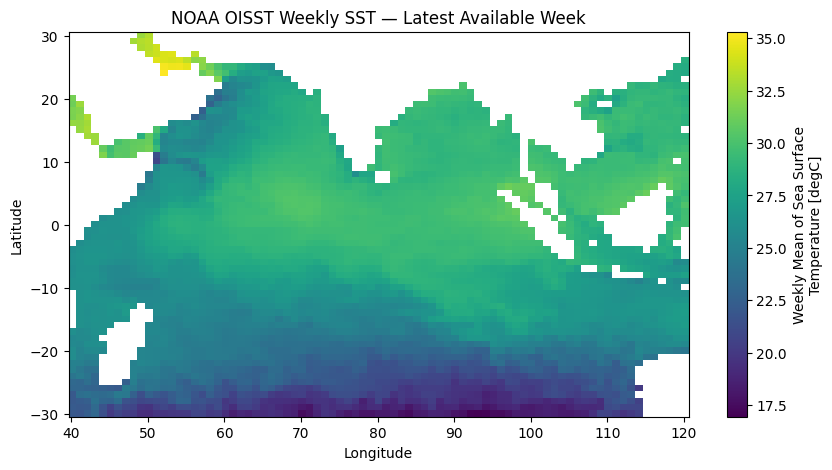

Latest week: 2026-08-30T00:00:00.000000000


In [31]:
# ============================================
# CELL 30 — Final Historical SST Plot
# ============================================

plt.figure(figsize=(10, 5))

full_ds["sst"].isel(time=-1).plot()

plt.title(
    "NOAA OISST Weekly SST — Latest Available Week"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

print(
    "Latest week:",
    full_ds.time.values[-1]
)

In [32]:
# ============================================
# CELL 31 — Reload Combined Dataset
# ============================================

combined_file = (
    data_dir / "oisst_weekly_indian_ocean_1deg.nc"
)

full_ds = xr.open_dataset(combined_file)

print(full_ds)

print("\nSST shape:")
print(full_ds["sst"].shape)

<xarray.Dataset> Size: 46MB
Dimensions:  (time: 2348, lat: 61, lon: 81)
Coordinates:
  * time     (time) datetime64[ns] 19kB 1981-09-06 1981-09-13 ... 2026-08-30
  * lat      (lat) float32 244B -29.88 -28.88 -27.88 ... 28.12 29.12 30.12
  * lon      (lon) float32 324B 40.12 41.12 42.12 43.12 ... 118.1 119.1 120.1
Data variables:
    sst      (time, lat, lon) float32 46MB ...
Attributes: (12/13)
    Conventions:         CF-1.5
    title:               NOAA/NCEI 1/4 Degree Daily Optimum Interpolation Sea...
    institution:         NOAA/National Centers for Environmental Information
    source:              NOAA/NCEI https://www.ncei.noaa.gov/data/sea-surface...
    References:          https://www.psl.noaa.gov/data/gridded/data.noaa.oiss...
    dataset_title:       NOAA Daily Optimum Interpolation Sea Surface Tempera...
    ...                  ...
    comment:             Reynolds, et al.(2007) Daily High-Resolution-Blended...
    History:             Translated to CF-1.0 Conventions b

In [33]:
# ============================================
# CELL 32 — Define IOD Regions
# ============================================

WEST_LON_MIN = 50
WEST_LON_MAX = 70
WEST_LAT_MIN = -10
WEST_LAT_MAX = 10

EAST_LON_MIN = 90
EAST_LON_MAX = 110
EAST_LAT_MIN = -10
EAST_LAT_MAX = 0

print("Western IOD box:")
print(
    f"Longitude: {WEST_LON_MIN}°E to {WEST_LON_MAX}°E"
)
print(
    f"Latitude : {WEST_LAT_MIN}° to {WEST_LAT_MAX}°"
)

print("\nEastern IOD box:")
print(
    f"Longitude: {EAST_LON_MIN}°E to {EAST_LON_MAX}°E"
)
print(
    f"Latitude : {EAST_LAT_MIN}° to {EAST_LAT_MAX}°"
)

Western IOD box:
Longitude: 50°E to 70°E
Latitude : -10° to 10°

Eastern IOD box:
Longitude: 90°E to 110°E
Latitude : -10° to 0°


In [34]:
# ============================================
# CELL 33 — Extract IOD SST Regions
# ============================================

west_sst = full_ds["sst"].sel(
    lat=slice(WEST_LAT_MIN, WEST_LAT_MAX),
    lon=slice(WEST_LON_MIN, WEST_LON_MAX)
)

east_sst = full_ds["sst"].sel(
    lat=slice(EAST_LAT_MIN, EAST_LAT_MAX),
    lon=slice(EAST_LON_MIN, EAST_LON_MAX)
)

print("Western SST shape:")
print(west_sst.shape)

print("\nEastern SST shape:")
print(east_sst.shape)

Western SST shape:
(2348, 20, 20)

Eastern SST shape:
(2348, 10, 20)


In [35]:
# ============================================
# CELL 34 — Weekly Spatial Mean SST
# ============================================

west_mean_sst = west_sst.mean(
    dim=["lat", "lon"],
    skipna=True
)

east_mean_sst = east_sst.mean(
    dim=["lat", "lon"],
    skipna=True
)

print("Western mean SST:")
print(west_mean_sst)

print("\nEastern mean SST:")
print(east_mean_sst)

Western mean SST:
<xarray.DataArray 'sst' (time: 2348)> Size: 9kB
array([26.934391, 27.0021  , 27.169912, ..., 27.964844, 27.943172,
       28.05988 ], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 19kB 1981-09-06 1981-09-13 ... 2026-08-30
Attributes:
    long_name:      Weekly Mean of Sea Surface Temperature
    units:          degC
    valid_range:    [-3. 45.]
    precision:      2.0
    dataset:        NOAA High-resolution Blended Analysis
    var_desc:       Sea Surface Temperature
    level_desc:     Surface
    statistic:      Weekly Mean
    parent_stat:    Individual Observations
    standard_name:  sea_surface_temperature
    actual_range:   [-1.8000001 32.14     ]

Eastern mean SST:
<xarray.DataArray 'sst' (time: 2348)> Size: 9kB
array([27.760027, 27.829668, 27.556915, ..., 28.581684, 28.659676,
       28.573372], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 19kB 1981-09-06 1981-09-13 ... 2026-08-30
Attributes:
    long_name:      Weekly Me

In [36]:
# ============================================
# CELL 35 — Weekly Climatology
# ============================================

# Convert time to pandas datetime
time_index = pd.DatetimeIndex(
    full_ds.time.values
)

# Week number
week_number = time_index.isocalendar().week.to_numpy()

# Convert to DataFrame for easy grouping
climatology_df = pd.DataFrame({
    "week": week_number,
    "west_sst": west_mean_sst.values,
    "east_sst": east_mean_sst.values
})

# Calculate climatological mean for each week
weekly_climatology = (
    climatology_df
    .groupby("week")[["west_sst", "east_sst"]]
    .mean()
)

print("Weekly climatology:")
print(weekly_climatology.head())

print(
    "\nNumber of climatological weeks:",
    len(weekly_climatology)
)

Weekly climatology:
       west_sst   east_sst
week                      
1     27.907379  28.609755
2     27.889006  28.542212
3     27.916832  28.562178
4     27.986855  28.506548
5     28.025730  28.572723

Number of climatological weeks: 53


In [37]:
# ============================================
# CELL 36 — Calculate Weekly SST Anomalies
# ============================================

west_anomalies = np.empty(
    len(west_mean_sst),
    dtype=np.float32
)

east_anomalies = np.empty(
    len(east_mean_sst),
    dtype=np.float32
)

for i, week in enumerate(week_number):

    west_anomalies[i] = (
        west_mean_sst.values[i]
        - weekly_climatology.loc[week, "west_sst"]
    )

    east_anomalies[i] = (
        east_mean_sst.values[i]
        - weekly_climatology.loc[week, "east_sst"]
    )

print("West anomaly range:")
print(
    west_anomalies.min(),
    "to",
    west_anomalies.max()
)

print("\nEast anomaly range:")
print(
    east_anomalies.min(),
    "to",
    east_anomalies.max()
)

West anomaly range:
-1.3484917 to 1.4435978

East anomaly range:
-1.8394184 to 1.4823704


In [38]:
# ============================================
# CELL 37 — Calculate Weekly DMI
# ============================================

dmi_values = (
    west_anomalies
    - east_anomalies
)

print("DMI range:")
print(
    dmi_values.min(),
    "to",
    dmi_values.max()
)

print("\nMean DMI:")
print(dmi_values.mean())

print("\nDMI standard deviation:")
print(dmi_values.std())

DMI range:
-1.7429237 to 2.2746105

Mean DMI:
2.5669598e-07

DMI standard deviation:
0.5292298


In [39]:
dmi_df = pd.DataFrame({
    "Date": time_index,
    "West_SST_Anomaly": west_anomalies,
    "East_SST_Anomaly": east_anomalies,
    "DMI": dmi_values
})

print(dmi_df.head(10))

print("\nShape:")
print(dmi_df.shape)

        Date  West_SST_Anomaly  East_SST_Anomaly       DMI
0 1981-09-06         -0.471491         -0.140869 -0.330622
1 1981-09-13         -0.543310         -0.020454 -0.522856
2 1981-09-20         -0.486826         -0.325134 -0.161692
3 1981-09-27         -0.529020          0.096075 -0.625095
4 1981-10-04         -0.205564          0.416315 -0.621880
5 1981-10-11         -0.055445         -0.061293  0.005848
6 1981-10-18         -0.181784         -0.134901 -0.046883
7 1981-10-25         -0.341328          0.003008 -0.344336
8 1981-11-01         -0.482285         -0.226713 -0.255571
9 1981-11-08         -0.167408          0.133055 -0.300463

Shape:
(2348, 4)


In [40]:
def classify_iod(dmi):

    if dmi >= 0.4:
        return "Positive"

    elif dmi <= -0.4:
        return "Negative"

    else:
        return "Neutral"


dmi_df["IOD_phase"] = (
    dmi_df["DMI"]
    .apply(classify_iod)
)

print(
    dmi_df[
        ["Date", "DMI", "IOD_phase"]
    ].head(20)
)

print("\nPhase counts:")
print(
    dmi_df["IOD_phase"].value_counts()
)

         Date       DMI IOD_phase
0  1981-09-06 -0.330622   Neutral
1  1981-09-13 -0.522856  Negative
2  1981-09-20 -0.161692   Neutral
3  1981-09-27 -0.625095  Negative
4  1981-10-04 -0.621880  Negative
5  1981-10-11  0.005848   Neutral
6  1981-10-18 -0.046883   Neutral
7  1981-10-25 -0.344336   Neutral
8  1981-11-01 -0.255571   Neutral
9  1981-11-08 -0.300463   Neutral
10 1981-11-15 -0.153269   Neutral
11 1981-11-22 -0.094721   Neutral
12 1981-11-29 -0.024805   Neutral
13 1981-12-06  0.217678   Neutral
14 1981-12-13 -0.529039  Negative
15 1981-12-20 -0.529779  Negative
16 1981-12-27 -0.214977   Neutral
17 1982-01-03 -0.252666   Neutral
18 1982-01-10  0.217718   Neutral
19 1982-01-17  0.407602  Positive

Phase counts:
IOD_phase
Neutral     1348
Negative     508
Positive     492
Name: count, dtype: int64


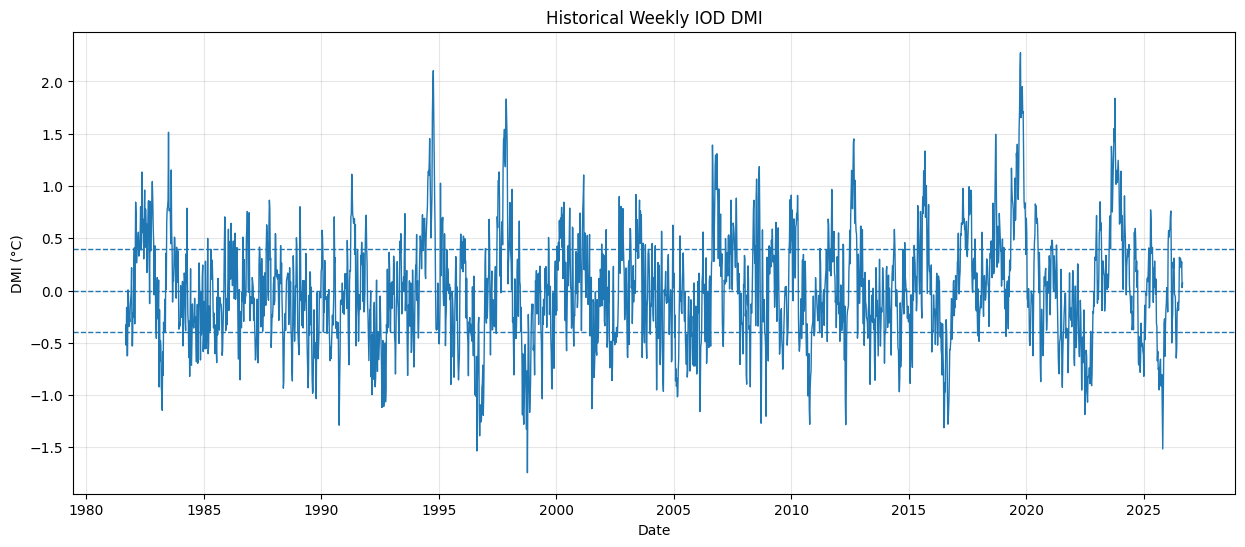

In [41]:
plt.figure(figsize=(15, 6))

plt.plot(
    dmi_df["Date"],
    dmi_df["DMI"],
    linewidth=1
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    0.4,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    -0.4,
    linestyle="--",
    linewidth=1
)

plt.title("Historical Weekly IOD DMI")

plt.xlabel("Date")
plt.ylabel("DMI (°C)")

plt.grid(True, alpha=0.3)

plt.show()

In [42]:
# ============================================
# Cell 41 — Chronological Train/Val/Test Split
# ============================================

n_total = len(full_ds.time)

train_end = int(n_total * 0.70)
val_end = int(n_total * 0.85)

train_indices = np.arange(0, train_end)
val_indices = np.arange(train_end, val_end)
test_indices = np.arange(val_end, n_total)

print("Total weeks:", n_total)

print("\nTrain:")
print("  Number of weeks:", len(train_indices))
print("  Start:", full_ds.time.values[train_indices[0]])
print("  End  :", full_ds.time.values[train_indices[-1]])

print("\nValidation:")
print("  Number of weeks:", len(val_indices))
print("  Start:", full_ds.time.values[val_indices[0]])
print("  End  :", full_ds.time.values[val_indices[-1]])

print("\nTest:")
print("  Number of weeks:", len(test_indices))
print("  Start:", full_ds.time.values[test_indices[0]])
print("  End  :", full_ds.time.values[test_indices[-1]])

Total weeks: 2348

Train:
  Number of weeks: 1643
  Start: 1981-09-06T00:00:00.000000000
  End  : 2013-02-24T00:00:00.000000000

Validation:
  Number of weeks: 352
  Start: 2013-03-03T00:00:00.000000000
  End  : 2019-11-24T00:00:00.000000000

Test:
  Number of weeks: 353
  Start: 2019-12-01T00:00:00.000000000
  End  : 2026-08-30T00:00:00.000000000


In [43]:
# ============================================
# Cell 42 — Split SST Dataset
# ============================================

train_ds = full_ds.isel(time=train_indices)
val_ds = full_ds.isel(time=val_indices)
test_ds = full_ds.isel(time=test_indices)

print("Train shape:")
print(train_ds["sst"].shape)

print("\nValidation shape:")
print(val_ds["sst"].shape)

print("\nTest shape:")
print(test_ds["sst"].shape)

Train shape:
(1643, 61, 81)

Validation shape:
(352, 61, 81)

Test shape:
(353, 61, 81)


In [44]:
# ============================================
# Cell 43 — Training Calendar Information
# ============================================

train_time_index = pd.DatetimeIndex(
    train_ds.time.values
)

val_time_index = pd.DatetimeIndex(
    val_ds.time.values
)

test_time_index = pd.DatetimeIndex(
    test_ds.time.values
)

train_week_number = (
    train_time_index
    .isocalendar()
    .week
    .to_numpy()
)

val_week_number = (
    val_time_index
    .isocalendar()
    .week
    .to_numpy()
)

test_week_number = (
    test_time_index
    .isocalendar()
    .week
    .to_numpy()
)

print("Training weeks:", len(train_week_number))
print("Validation weeks:", len(val_week_number))
print("Test weeks:", len(test_week_number))

print("\nFirst 10 training ISO weeks:")
print(train_week_number[:10])

Training weeks: 1643
Validation weeks: 352
Test weeks: 353

First 10 training ISO weeks:
[36 37 38 39 40 41 42 43 44 45]


In [45]:
# ============================================
# Cell 44 — Training SST Means
# ============================================

train_west_sst = train_ds["sst"].sel(
    lat=slice(WEST_LAT_MIN, WEST_LAT_MAX),
    lon=slice(WEST_LON_MIN, WEST_LON_MAX)
)

train_east_sst = train_ds["sst"].sel(
    lat=slice(EAST_LAT_MIN, EAST_LAT_MAX),
    lon=slice(EAST_LON_MIN, EAST_LON_MAX)
)

train_west_mean_sst = train_west_sst.mean(
    dim=["lat", "lon"],
    skipna=True
)

train_east_mean_sst = train_east_sst.mean(
    dim=["lat", "lon"],
    skipna=True
)

print("Training West SST:")
print(train_west_mean_sst.shape)

print("\nTraining East SST:")
print(train_east_mean_sst.shape)

Training West SST:
(1643,)

Training East SST:
(1643,)


In [46]:
# ============================================
# Cell 45 — Training-Only Weekly Climatology
# ============================================

train_climatology_df = pd.DataFrame({
    "week": train_week_number,
    "west_sst": train_west_mean_sst.values,
    "east_sst": train_east_mean_sst.values
})

training_weekly_climatology = (
    train_climatology_df
    .groupby("week")[["west_sst", "east_sst"]]
    .mean()
)

print("Training-only climatology:")
print(
    training_weekly_climatology.head(10)
)

print(
    "\nNumber of climatological weeks:",
    len(training_weekly_climatology)
)

Training-only climatology:
       west_sst   east_sst
week                      
1     27.807421  28.485720
2     27.785444  28.413168
3     27.803202  28.476107
4     27.888664  28.411766
5     27.919456  28.493275
6     28.012959  28.584993
7     28.197573  28.634075
8     28.335758  28.688583
9     28.503349  28.769678
10    28.649168  28.872826

Number of climatological weeks: 53


In [47]:
# ============================================
# Cell 46 — Leakage-Free DMI Function
# ============================================

def calculate_dmi_from_dataset(
    ds,
    weekly_climatology
):

    time_index = pd.DatetimeIndex(
        ds.time.values
    )

    week_numbers = (
        time_index
        .isocalendar()
        .week
        .to_numpy()
    )

    west_sst = ds["sst"].sel(
        lat=slice(WEST_LAT_MIN, WEST_LAT_MAX),
        lon=slice(WEST_LON_MIN, WEST_LON_MAX)
    )

    east_sst = ds["sst"].sel(
        lat=slice(EAST_LAT_MIN, EAST_LAT_MAX),
        lon=slice(EAST_LON_MIN, EAST_LON_MAX)
    )

    west_mean = west_sst.mean(
        dim=["lat", "lon"],
        skipna=True
    )

    east_mean = east_sst.mean(
        dim=["lat", "lon"],
        skipna=True
    )

    west_anomaly = np.array([
        west_mean.values[i]
        - weekly_climatology.loc[
            week,
            "west_sst"
        ]
        for i, week in enumerate(week_numbers)
    ])

    east_anomaly = np.array([
        east_mean.values[i]
        - weekly_climatology.loc[
            week,
            "east_sst"
        ]
        for i, week in enumerate(week_numbers)
    ])

    dmi = west_anomaly - east_anomaly

    return (
        time_index,
        week_numbers,
        west_anomaly,
        east_anomaly,
        dmi
    )

In [48]:
# ============================================
# Cell 47 — Leakage-Free DMI
# ============================================

(
    train_dates,
    train_weeks,
    train_west_anomaly,
    train_east_anomaly,
    train_dmi
) = calculate_dmi_from_dataset(
    train_ds,
    training_weekly_climatology
)

(
    val_dates,
    val_weeks,
    val_west_anomaly,
    val_east_anomaly,
    val_dmi
) = calculate_dmi_from_dataset(
    val_ds,
    training_weekly_climatology
)

(
    test_dates,
    test_weeks,
    test_west_anomaly,
    test_east_anomaly,
    test_dmi
) = calculate_dmi_from_dataset(
    test_ds,
    training_weekly_climatology
)

print("Train DMI shape:", train_dmi.shape)
print("Validation DMI shape:", val_dmi.shape)
print("Test DMI shape:", test_dmi.shape)

print("\nTrain DMI range:")
print(train_dmi.min(), "to", train_dmi.max())

print("\nValidation DMI range:")
print(val_dmi.min(), "to", val_dmi.max())

print("\nTest DMI range:")
print(test_dmi.min(), "to", test_dmi.max())

Train DMI shape: (1643,)
Validation DMI shape: (352,)
Test DMI shape: (353,)

Train DMI range:
-1.7155457 to 2.1932755

Validation DMI range:
-1.3314953 to 2.3650665

Test DMI range:
-1.4908466 to 1.86623


In [49]:
# ============================================
# Cell 48 — Train/Val/Test DMI Tables
# ============================================

train_dmi_df = pd.DataFrame({
    "Date": train_dates,
    "DMI": train_dmi
})

val_dmi_df = pd.DataFrame({
    "Date": val_dates,
    "DMI": val_dmi
})

test_dmi_df = pd.DataFrame({
    "Date": test_dates,
    "DMI": test_dmi
})

train_dmi_df["IOD_phase"] = (
    train_dmi_df["DMI"]
    .apply(classify_iod)
)

val_dmi_df["IOD_phase"] = (
    val_dmi_df["DMI"]
    .apply(classify_iod)
)

test_dmi_df["IOD_phase"] = (
    test_dmi_df["DMI"]
    .apply(classify_iod)
)

print("TRAIN")
print(train_dmi_df.head())

print("\nVALIDATION")
print(val_dmi_df.head())

print("\nTEST")
print(test_dmi_df.head())

TRAIN
        Date       DMI IOD_phase
0 1981-09-06 -0.330235   Neutral
1 1981-09-13 -0.477831  Negative
2 1981-09-20 -0.123217   Neutral
3 1981-09-27 -0.538322  Negative
4 1981-10-04 -0.531424  Negative

VALIDATION
        Date       DMI IOD_phase
0 2013-03-03 -0.112358   Neutral
1 2013-03-10 -0.056419   Neutral
2 2013-03-17 -0.219158   Neutral
3 2013-03-24 -0.281054   Neutral
4 2013-03-31 -0.334957   Neutral

TEST
        Date       DMI IOD_phase
0 2019-12-01  0.908726  Positive
1 2019-12-08  0.806128  Positive
2 2019-12-15  0.868078  Positive
3 2019-12-22  0.714779  Positive
4 2019-12-29  0.363312   Neutral


In [50]:
# ============================================
# Cell 49 — Phase Distribution
# ============================================

print("TRAIN phase distribution:")
print(
    train_dmi_df["IOD_phase"]
    .value_counts()
)

print("\nVALIDATION phase distribution:")
print(
    val_dmi_df["IOD_phase"]
    .value_counts()
)

print("\nTEST phase distribution:")
print(
    test_dmi_df["IOD_phase"]
    .value_counts()
)

TRAIN phase distribution:
IOD_phase
Neutral     958
Positive    346
Negative    339
Name: count, dtype: int64

VALIDATION phase distribution:
IOD_phase
Neutral     202
Positive     98
Negative     52
Name: count, dtype: int64

TEST phase distribution:
IOD_phase
Neutral     192
Negative     83
Positive     78
Name: count, dtype: int64


In [51]:
# ============================================
# Cell 50 — Compare DMI Calculations
# ============================================

comparison_df = pd.DataFrame({
    "Date": time_index,
    "Exploratory_DMI": dmi_values
})

leakage_free_dmi = np.concatenate([
    train_dmi,
    val_dmi,
    test_dmi
])

comparison_df["Leakage_Free_DMI"] = (
    leakage_free_dmi
)

comparison_df["Difference"] = (
    comparison_df["Leakage_Free_DMI"]
    - comparison_df["Exploratory_DMI"]
)

print(comparison_df.head(20))

print("\nMaximum absolute difference:")
print(
    comparison_df["Difference"]
    .abs()
    .max()
)

print("\nMean absolute difference:")
print(
    comparison_df["Difference"]
    .abs()
    .mean()
)

         Date  Exploratory_DMI  Leakage_Free_DMI  Difference
0  1981-09-06        -0.330622         -0.330235    0.000387
1  1981-09-13        -0.522856         -0.477831    0.045025
2  1981-09-20        -0.161692         -0.123217    0.038475
3  1981-09-27        -0.625095         -0.538322    0.086773
4  1981-10-04        -0.621880         -0.531424    0.090456
5  1981-10-11         0.005848          0.033226    0.027378
6  1981-10-18        -0.046883         -0.055275   -0.008392
7  1981-10-25        -0.344336         -0.319427    0.024908
8  1981-11-01        -0.255571         -0.177605    0.077967
9  1981-11-08        -0.300463         -0.240072    0.060390
10 1981-11-15        -0.153269         -0.101746    0.051523
11 1981-11-22        -0.094721         -0.024632    0.070089
12 1981-11-29        -0.024805          0.027863    0.052668
13 1981-12-06         0.217678          0.233089    0.015411
14 1981-12-13        -0.529039         -0.500505    0.028534
15 1981-12-20        -0.

In [52]:
# ============================================
# Cell 51 — Training-Only SST Anomalies
# ============================================

# Get training SST
train_sst = train_ds["sst"]

# Calendar information
train_time_index = pd.DatetimeIndex(
    train_ds.time.values
)

train_week_numbers = (
    train_time_index
    .isocalendar()
    .week
    .to_numpy()
)

# Convert climatology to arrays
west_clim = np.array([
    training_weekly_climatology.loc[
        week, "west_sst"
    ]
    for week in train_week_numbers
])

east_clim = np.array([
    training_weekly_climatology.loc[
        week, "east_sst"
    ]
    for week in train_week_numbers
])

print("Training SST shape:")
print(train_sst.shape)

print("\nNumber of training weeks:")
print(len(train_week_numbers))

Training SST shape:
(1643, 61, 81)

Number of training weeks:
1643


In [53]:
# ============================================
# Cell 52 — Spatial Weekly Climatology
# ============================================

train_sst_values = train_sst.values.astype(
    np.float32
)

print("Training SST array:")
print(train_sst_values.shape)

# Store weekly climatology for every grid cell
spatial_weekly_climatology = np.full(
    (53, len(full_ds.lat), len(full_ds.lon)),
    np.nan,
    dtype=np.float32
)

for week in range(1, 54):

    week_mask = (
        train_week_numbers == week
    )

    if np.any(week_mask):

        spatial_weekly_climatology[
            week - 1
        ] = np.nanmean(
            train_sst_values[week_mask],
            axis=0
        )

print(
    "Spatial climatology shape:"
)

print(
    spatial_weekly_climatology.shape
)

Training SST array:
(1643, 61, 81)
Spatial climatology shape:
(53, 61, 81)


/tmp/ipykernel_884/1610553337.py:29: RuntimeWarning: Mean of empty slice
  ] = np.nanmean(


In [54]:
# ============================================
# Cell 53 — Training SST Anomalies
# ============================================

train_sst_anomaly = np.empty_like(
    train_sst_values,
    dtype=np.float32
)

for i, week in enumerate(train_week_numbers):

    climatology_map = spatial_weekly_climatology[week - 1]

    train_sst_anomaly[i] = (
        train_sst_values[i] - climatology_map
    )

print("Training anomaly shape:")
print(train_sst_anomaly.shape)

print("Anomaly minimum:")
print(np.nanmin(train_sst_anomaly))

print("Anomaly maximum:")
print(np.nanmax(train_sst_anomaly))

print("Anomaly mean:")
print(np.nanmean(train_sst_anomaly))

Training anomaly shape:
(1643, 61, 81)
Anomaly minimum:
-6.3745155
Anomaly maximum:
5.896454
Anomaly mean:
-8.220906e-09


In [55]:
# ============================================
# Cell 54 — Validation SST Anomalies
# ============================================

val_sst_values = val_ds["sst"].values.astype(
    np.float32
)

val_sst_anomaly = np.empty_like(
    val_sst_values,
    dtype=np.float32
)

for i, week in enumerate(val_week_number):

    # IMPORTANT:
    # Use TRAINING climatology only
    climatology_map = spatial_weekly_climatology[week - 1]

    val_sst_anomaly[i] = (
        val_sst_values[i] - climatology_map
    )

print("Validation anomaly shape:")
print(val_sst_anomaly.shape)

print(
    "Validation anomaly range:",
    np.nanmin(val_sst_anomaly),
    "to",
    np.nanmax(val_sst_anomaly)
)

print(
    "Validation anomaly mean:",
    np.nanmean(val_sst_anomaly)
)

Validation anomaly shape:
(352, 61, 81)
Validation anomaly range: -8.26989 to 7.1381245
Validation anomaly mean: 0.41204646


In [56]:
# ============================================
# Cell 55 — Test SST Anomalies
# ============================================

test_sst_values = test_ds["sst"].values.astype(
    np.float32
)

test_sst_anomaly = np.empty_like(
    test_sst_values,
    dtype=np.float32
)

for i, week in enumerate(test_week_number):

    # IMPORTANT:
    # Use TRAINING climatology only
    climatology_map = spatial_weekly_climatology[week - 1]

    test_sst_anomaly[i] = (
        test_sst_values[i] - climatology_map
    )

print("Test anomaly shape:")
print(test_sst_anomaly.shape)

print(
    "Test anomaly range:",
    np.nanmin(test_sst_anomaly),
    "to",
    np.nanmax(test_sst_anomaly)
)

print(
    "Test anomaly mean:",
    np.nanmean(test_sst_anomaly)
)

Test anomaly shape:
(353, 61, 81)
Test anomaly range: -7.470806 to 4.799835
Test anomaly mean: 0.5651079


In [57]:
# ============================================
# Cell 56 — Create Ocean Mask
# ============================================

# A grid cell is considered ocean if it has
# at least one valid SST observation in training.

ocean_mask = np.any(
    ~np.isnan(train_sst_values),
    axis=0
)

print("Ocean grid cells:")
print(np.sum(ocean_mask))

print("Land/unavailable grid cells:")
print(np.sum(~ocean_mask))

print("Total grid cells:")
print(ocean_mask.size)

Ocean grid cells:
3606
Land/unavailable grid cells:
1335
Total grid cells:
4941


In [58]:
# ============================================
# Cell 57 — Apply Ocean Mask
# ============================================

# Make sure land cells are NaN in all datasets.
# The same geographic mask is used for train,
# validation, and test.

train_sst_anomaly[:, ~ocean_mask] = np.nan

val_sst_anomaly[:, ~ocean_mask] = np.nan

test_sst_anomaly[:, ~ocean_mask] = np.nan

print("Ocean mask applied successfully.")

print(
    "Training NaN count:",
    np.isnan(train_sst_anomaly).sum()
)

print(
    "Validation NaN count:",
    np.isnan(val_sst_anomaly).sum()
)

print(
    "Test NaN count:",
    np.isnan(test_sst_anomaly).sum()
)

Ocean mask applied successfully.
Training NaN count: 2193405
Validation NaN count: 469920
Test NaN count: 471255


In [59]:
# ============================================
# Cell 58 — Replace Land NaNs with Zero
# ============================================

train_sst_anomaly = np.nan_to_num(
    train_sst_anomaly,
    nan=0.0
)

val_sst_anomaly = np.nan_to_num(
    val_sst_anomaly,
    nan=0.0
)

test_sst_anomaly = np.nan_to_num(
    test_sst_anomaly,
    nan=0.0
)

print("NaNs replaced with zero.")

print(
    "Training NaNs:",
    np.isnan(train_sst_anomaly).sum()
)

print(
    "Validation NaNs:",
    np.isnan(val_sst_anomaly).sum()
)

print(
    "Test NaNs:",
    np.isnan(test_sst_anomaly).sum()
)

print(
    "Training shape:",
    train_sst_anomaly.shape
)

print(
    "Validation shape:",
    val_sst_anomaly.shape
)

print(
    "Test shape:",
    test_sst_anomaly.shape
)

NaNs replaced with zero.
Training NaNs: 0
Validation NaNs: 0
Test NaNs: 0
Training shape: (1643, 61, 81)
Validation shape: (352, 61, 81)
Test shape: (353, 61, 81)


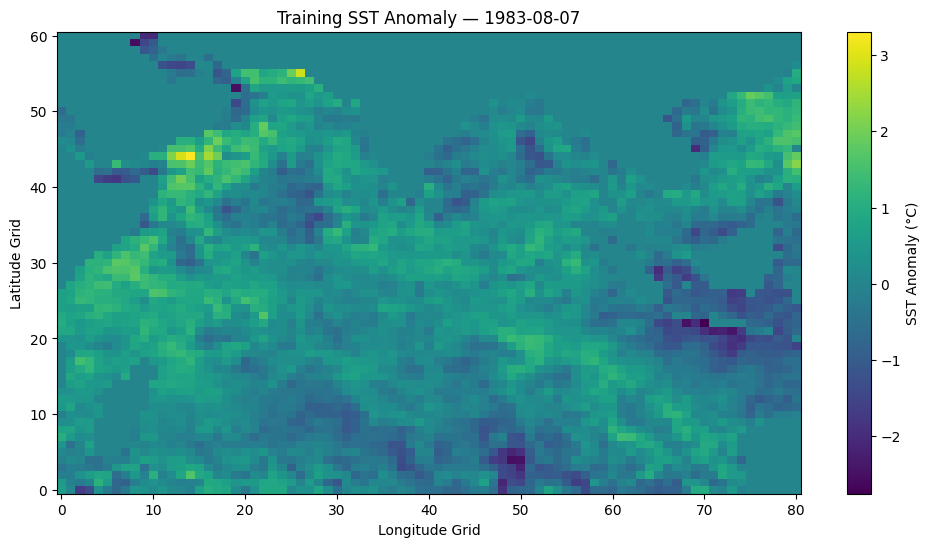

In [60]:
# ============================================
# Cell 59 — Visualize SST Anomaly
# ============================================

sample_index = 100

plt.figure(figsize=(12, 6))

plt.imshow(
    train_sst_anomaly[sample_index],
    origin="lower",
    aspect="auto"
)

plt.colorbar(
    label="SST Anomaly (°C)"
)

plt.title(
    f"Training SST Anomaly — "
    f"{pd.Timestamp(train_ds.time.values[sample_index]).date()}"
)

plt.xlabel("Longitude Grid")
plt.ylabel("Latitude Grid")

plt.show()

In [61]:
# ============================================
# Cell 60 — Save Preprocessing Artifacts
# ============================================

# Save the weekly spatial climatology
np.save(
    artifact_dir / "spatial_weekly_climatology.npy",
    spatial_weekly_climatology
)

# Save the ocean/land mask
np.save(
    artifact_dir / "ocean_mask.npy",
    ocean_mask
)

print("Saved preprocessing artifacts:")

print(
    artifact_dir / "spatial_weekly_climatology.npy"
)

print(
    artifact_dir / "ocean_mask.npy"
)

print()
print("Climatology shape:", spatial_weekly_climatology.shape)
print("Ocean mask shape:", ocean_mask.shape)

Saved preprocessing artifacts:
saarthi_iod_artifacts/spatial_weekly_climatology.npy
saarthi_iod_artifacts/ocean_mask.npy

Climatology shape: (53, 61, 81)
Ocean mask shape: (61, 81)
